# Solar Irradiance Prediction — Data Preprocessing & Exploratory Data Analysis
---
| | |
|---|---|
| **Thesis Title** | A Machine Learning Approach to Solar Irradiance Prediction Using Historical Weather Data |
| **Programme** | B.Sc. Internet Informatics |
| **Institution** | Kaunas University of Technology |
| **Notebook** | 01 — Data Preprocessing & EDA |
| **Data Source** | NREL National Solar Radiation Database (NSRDB), SPAIN Region, 2022 |
| **Target Variable** | Global Horizontal Irradiance — GHI (W/m²) |

---
### Notebook Objectives
This notebook performs all data preparation steps required before model training:
1. Load and inspect the raw NSRDB dataset
2. Parse and validate the datetime index
3. Assess data quality (missing values, fill flags, outliers)
4. Perform exploratory data analysis (EDA) on GHI and meteorological features
5. Select the most relevant features via correlation analysis and delete the unwanted ones
6. Produce a clean dataset 

## Table of Contents
1. [Environment Setup](#setup)
2. [Dataset Description](#dataset)
3. [Data Loading](#loading)
4. [DateTime Index](#datetime)
5. [Data Quality Assessment](#quality)
6. [Outlier Detection](#outliers)
7. [Exploratory Data Analysis](#eda)
8. [Feature Selection & Correlation Analysis](#feature)
9. [Export Processed Data](#export)
10. [Preprocessing Summary](#summary)

<a id="setup"></a>
## 1. Environment Setup

In [2]:
# Core libraries
import pandas as pd
import numpy as np
pd.set_option('display.max_columns', None)

import matplotlib.pyplot as plt
import seaborn as sns

---
<a id="dataset"></a>
## 2. Dataset Description
NSRDB CSV exports contain **two metadata rows** before the column headers. We first inspect those rows to extract station metadata, then reload the file with `skiprows=2` to obtain a clean DataFrame.

In [2]:
raw_data=pd.read_csv("../data/solar2022.csv")

In [3]:
raw_data.head()

,Source,Location ID,City,State,Country,Latitude,Longitude,Time Zone,Elevation,Local Time Zone,Clearsky DHI Units,Clearsky DNI Units,Clearsky GHI Units,Dew Point Units,DHI Units,DNI Units,GHI Units,Solar Zenith Angle Units,Temperature Units,Pressure Units,Relative Humidity Units,Precipitable Water Units,Wind Direction Units,Wind Speed Units,Cloud Type -15,Cloud Type 0,Cloud Type 1,Cloud Type 2,Cloud Type 3,Cloud Type 4,Cloud Type 5,Cloud Type 6,Cloud Type 7,Cloud Type 8,Cloud Type 9,Cloud Type 10,Cloud Type 11,Cloud Type 12,Fill Flag 0,Fill Flag 1,Fill Flag 2,Fill Flag 3,Fill Flag 4,Fill Flag 5,Surface Albedo Units,Version
0,NSRDB,223700,-,-,-,40.97,-4.54,1,895,1,w/m2,w/m2,w/m2,c,w/m2,w/m2,w/m2,Degree,c,mbar,%,cm,Degrees,m/s,NaN,Clear,Probably Clear,Fog,Water,Super-Cooled Water,Mixed,Opaque Ice,Cirrus,Overlapping,Overshooting,Unknown,Dust,Smoke,NaN,Missing Image,Low Irradiance,Exceeds Clearsky,Missing CLoud Properties,Rayleigh Violation,NaN,4.0.0
1,Year,Month,Day,Hour,Minute,Temperature,Clearsky DHI,Clearsky DNI,Clearsky GHI,Cloud Type,Relative Humidity,Pressure,Wind Direction,Wind Speed,DHI,DNI,GHI,Solar Zenith Angle,Precipitable Water,Surface Albedo,Fill Flag,Dew Point,Asymmetry,Aerosol Optical Depth,Alpha,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2022,1,1,0,30,4.9,0,0,0,1,69.27,914,172,3.4000000000000004,0,0,0,159.08,1.4000000000000001,0.17,0,-0.30000000000000004,0.67,0.07100000000000001,0.4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2022,1,1,1,30,5.2,0,0,0,4,57.26,918,183,1.6,0,0,0,161.96,0.5,0.16,0,-2.6,0.64,0.011,1.02,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2022,1,1,2,30,5.300000000000001,0,0,0,0,55.49,919,184,1.5,0,0,0,157,0.5,0.16,0,-2.9000000000000004,0.64,0.011,1.04,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [4]:
raw_data.head(2)

,Source,Location ID,City,State,Country,Latitude,Longitude,Time Zone,Elevation,Local Time Zone,Clearsky DHI Units,Clearsky DNI Units,Clearsky GHI Units,Dew Point Units,DHI Units,DNI Units,GHI Units,Solar Zenith Angle Units,Temperature Units,Pressure Units,Relative Humidity Units,Precipitable Water Units,Wind Direction Units,Wind Speed Units,Cloud Type -15,Cloud Type 0,Cloud Type 1,Cloud Type 2,Cloud Type 3,Cloud Type 4,Cloud Type 5,Cloud Type 6,Cloud Type 7,Cloud Type 8,Cloud Type 9,Cloud Type 10,Cloud Type 11,Cloud Type 12,Fill Flag 0,Fill Flag 1,Fill Flag 2,Fill Flag 3,Fill Flag 4,Fill Flag 5,Surface Albedo Units,Version
0,NSRDB,223700,-,-,-,40.97,-4.54,1,895,1,w/m2,w/m2,w/m2,c,w/m2,w/m2,w/m2,Degree,c,mbar,%,cm,Degrees,m/s,NaN,Clear,Probably Clear,Fog,Water,Super-Cooled Water,Mixed,Opaque Ice,Cirrus,Overlapping,Overshooting,Unknown,Dust,Smoke,NaN,Missing Image,Low Irradiance,Exceeds Clearsky,Missing CLoud Properties,Rayleigh Violation,NaN,4.0.0
1,Year,Month,Day,Hour,Minute,Temperature,Clearsky DHI,Clearsky DNI,Clearsky GHI,Cloud Type,Relative Humidity,Pressure,Wind Direction,Wind Speed,DHI,DNI,GHI,Solar Zenith Angle,Precipitable Water,Surface Albedo,Fill Flag,Dew Point,Asymmetry,Aerosol Optical Depth,Alpha,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [5]:
data_info= raw_data.loc[0]

In [6]:
print(data_info)

Source                                         NSRDB
Location ID                                   223700
City                                               -
State                                              -
Country                                            -
Latitude                                       40.97
Longitude                                      -4.54
Time Zone                                          1
Elevation                                        895
Local Time Zone                                    1
Clearsky DHI Units                              w/m2
Clearsky DNI Units                              w/m2
Clearsky GHI Units                              w/m2
Dew Point Units                                    c
DHI Units                                       w/m2
DNI Units                                       w/m2
GHI Units                                       w/m2
Solar Zenith Angle Units                      Degree
Temperature Units                             

In [6]:
df=pd.read_csv("../data/solar2022.csv",skiprows = 2)

In [8]:
df.head(5)

,Year,Month,Day,Hour,Minute,Temperature,Clearsky DHI,Clearsky DNI,Clearsky GHI,Cloud Type,Relative Humidity,Pressure,Wind Direction,Wind Speed,DHI,DNI,GHI,Solar Zenith Angle,Precipitable Water,Surface Albedo,Fill Flag,Dew Point,Asymmetry,Aerosol Optical Depth,Alpha
0,2022,1,1,0,30,4.9,0,0,0,1,69.27,914,172,3.4,0,0,0,159.08,1.4,0.17,0,-0.3,0.67,0.071,0.40
1,2022,1,1,1,30,5.2,0,0,0,4,57.26,918,183,1.6,0,0,0,161.96,0.5,0.16,0,-2.6,0.64,0.011,1.02
2,2022,1,1,2,30,5.3,0,0,0,0,55.49,919,184,1.5,0,0,0,157.00,0.5,0.16,0,-2.9,0.64,0.011,1.04
3,2022,1,1,3,30,5.3,0,0,0,0,54.39,919,184,1.5,0,0,0,147.66,0.5,0.16,0,-3.2,0.64,0.011,1.07
4,2022,1,1,4,30,5.3,0,0,0,4,53.39,919,184,1.4,0,0,0,136.82,0.5,0.16,0,-3.4,0.64,0.011,1.08


In [9]:
df.tail(5)

,Year,Month,Day,Hour,Minute,Temperature,Clearsky DHI,Clearsky DNI,Clearsky GHI,Cloud Type,Relative Humidity,Pressure,Wind Direction,Wind Speed,DHI,DNI,GHI,Solar Zenith Angle,Precipitable Water,Surface Albedo,Fill Flag,Dew Point,Asymmetry,Aerosol Optical Depth,Alpha
8755,2022,12,31,19,30,6.2,0,0,0,3,66.17,914,176,3.5,0,0,0,106.46,1.4,0.17,0,0.4,0.67,0.052,0.31
8756,2022,12,31,20,30,5.7,0,0,0,4,68.11,915,174,3.4,0,0,0,117.52,1.4,0.17,0,0.3,0.67,0.055,0.32
8757,2022,12,31,21,30,5.3,0,0,0,4,69.63,915,173,3.2,0,0,0,128.81,1.4,0.17,0,0.2,0.67,0.060,0.32
8758,2022,12,31,22,30,5.0,0,0,0,1,70.24,914,173,3.3,0,0,0,140.02,1.4,0.17,0,0.0,0.67,0.064,0.34
8759,2022,12,31,23,30,4.9,0,0,0,8,69.86,914,172,3.4,0,0,0,150.59,1.4,0.17,0,-0.1,0.67,0.068,0.37


In [10]:
df.shape

(8760, 25)

---
<a id="loading"></a>
## 3. Data Loading
| Column | Unit | Description |
|---|---|---|
| **GHI** | W/m² | **Target.** Global Horizontal Irradiance — total shortwave solar radiation received on a horizontal surface |
| **DNI** | W/m² | Direct Normal Irradiance — solar radiation received per unit area on a surface perpendicular to the sun's rays |
| **DHI** | W/m² | Diffuse Horizontal Irradiance — scattered solar radiation received from the sky dome on a horizontal surface |
| **Clearsky GHI** | W/m² | Modelled GHI under cloud-free atmospheric conditions (PSM v3 clear-sky model) |
| **Clearsky DNI** | W/m² | Modelled DNI under cloud-free conditions |
| **Clearsky DHI** | W/m² | Modelled DHI under cloud-free conditions |
| **Solar Zenith Angle** | ° | Angle between the sun and the local vertical (0° = sun directly overhead; 90° = horizon) |
| **Cloud Type** | category | NSRDB cloud classification code (0 = clear, 1–8 = cloud type categories) |
| **Temperature** | °C | Air temperature at 2 m above ground level |
| **Relative Humidity** | % | Ratio of actual water vapour pressure to saturation vapour pressure at 2 m |
| **Dew Point** | °C | Temperature at which air becomes saturated with water vapour at constant pressure |
| **Precipitable Water** | cm | Total atmospheric water vapour in a vertical column from surface to top of atmosphere |
| **Wind Speed** | m/s | Wind speed at 10 m above ground level |
| **Wind Direction** | ° | Wind direction at 10 m (0° = North, 90° = East, 180° = South, 270° = West) |
| **Pressure** | mbar | Atmospheric pressure at the surface |
| **Surface Albedo** | — | Fraction of incoming solar radiation reflected by the surface (0 = fully absorbing, 1 = fully reflecting) |
| **Aerosol Optical Depth** | — | Measure of aerosol particle extinction of solar radiation through the atmosphere |
| **Alpha** | — | Ångström exponent — describes the spectral dependence of aerosol optical depth |
| **Asymmetry** | — | Aerosol scattering asymmetry parameter — describes the angular distribution of scattered radiation |
| **Fill Flag** | — | Data quality flag: `0` = directly measured; non-zero = gap-filled or QC-adjusted by NREL PSM v3 |


In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8760 entries, 0 to 8759
Data columns (total 25 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Year                   8760 non-null   int64  
 1   Month                  8760 non-null   int64  
 2   Day                    8760 non-null   int64  
 3   Hour                   8760 non-null   int64  
 4   Minute                 8760 non-null   int64  
 5   Temperature            8760 non-null   float64
 6   Clearsky DHI           8760 non-null   int64  
 7   Clearsky DNI           8760 non-null   int64  
 8   Clearsky GHI           8760 non-null   int64  
 9   Cloud Type             8760 non-null   int64  
 10  Relative Humidity      8760 non-null   float64
 11  Pressure               8760 non-null   int64  
 12  Wind Direction         8760 non-null   int64  
 13  Wind Speed             8760 non-null   float64
 14  DHI                    8760 non-null   int64  
 15  DNI 

In [12]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Year,8760.0,2022.000000,0.000000,2022.00,2022.000,2022.000,2022.000,2022.000
Month,8760.0,6.526027,3.448048,1.00,4.000,7.000,10.000,12.000
Day,8760.0,15.720548,8.796749,1.00,8.000,16.000,23.000,31.000
Hour,8760.0,11.500000,6.922582,0.00,5.750,11.500,17.250,23.000
Minute,8760.0,30.000000,0.000000,30.00,30.000,30.000,30.000,30.000
Temperature,8760.0,13.501747,9.172793,-4.80,6.300,12.100,19.900,39.100
Clearsky DHI,8760.0,38.967237,49.824015,0.00,0.000,0.000,71.000,343.000
Clearsky DNI,8760.0,370.407078,405.005444,0.00,0.000,0.000,823.000,1027.000
Clearsky GHI,8760.0,240.614155,315.734227,0.00,0.000,0.000,469.000,1031.000
Cloud Type,8760.0,2.901027,3.098291,0.00,0.000,1.000,6.000,9.000


---
<a id="datetime"></a>
## 4. DateTime Index

The NSRDB dataset stores date/time components as separate integer columns
(Year, Month, Day, Hour, Minute). We combine them into a proper
`DatetimeIndex` to enable time-series-aware operations throughout the
pipeline.

In [11]:
df['Date Time']=pd.to_datetime(df[['Year', 'Month', 'Day', 'Hour', 'Minute']])

In [12]:
df.set_index('Date Time',inplace=True)

In [13]:
df=df.sort_index()

In [14]:
df.drop(columns=['Year', 'Month', 'Day', 'Hour', 'Minute'], inplace=True)

In [15]:
df.head()

,Temperature,Clearsky DHI,Clearsky DNI,Clearsky GHI,Cloud Type,Relative Humidity,Pressure,Wind Direction,Wind Speed,DHI,DNI,GHI,Solar Zenith Angle,Precipitable Water,Surface Albedo,Fill Flag,Dew Point,Asymmetry,Aerosol Optical Depth,Alpha
Date Time,,,,,,,,,,,,,,,,,,,,
2022-01-01 00:30:00,4.9,0,0,0,1,69.27,914,172,3.4,0,0,0,159.08,1.4,0.17,0,-0.3,0.67,0.071,0.40
2022-01-01 01:30:00,5.2,0,0,0,4,57.26,918,183,1.6,0,0,0,161.96,0.5,0.16,0,-2.6,0.64,0.011,1.02
2022-01-01 02:30:00,5.3,0,0,0,0,55.49,919,184,1.5,0,0,0,157.00,0.5,0.16,0,-2.9,0.64,0.011,1.04
2022-01-01 03:30:00,5.3,0,0,0,0,54.39,919,184,1.5,0,0,0,147.66,0.5,0.16,0,-3.2,0.64,0.011,1.07
2022-01-01 04:30:00,5.3,0,0,0,4,53.39,919,184,1.4,0,0,0,136.82,0.5,0.16,0,-3.4,0.64,0.011,1.08


### 4.1 Temporal Integrity Check
<!-- [ADDED] — verifies the datetime index is complete with no gaps or duplicates -->
For an hourly dataset covering a full year, we expect exactly **8,760 rows** (365 days × 24 hours).
Any missing timestamps or duplicates would need to be resolved before modelling.

In [16]:
expected_freq = '1h'
full_range    = pd.date_range(start=df.index.min(), end=df.index.max(), freq=expected_freq)
missing_ts    = full_range.difference(df.index)
duplicate_ts  = df.index[df.index.duplicated()]

print(f"Expected rows (1-hour, full year) : {len(full_range):,}")
print(f"Actual rows                       : {len(df):,}")
print(f"Missing timestamps                : {len(missing_ts)}")
print(f"Duplicate timestamps              : {len(duplicate_ts)}")

if len(missing_ts) == 0 and len(duplicate_ts) == 0:
    print("\n Datetime index is complete — no gaps or duplicates found.")

Expected rows (1-hour, full year) : 8,760
Actual rows                       : 8,760
Missing timestamps                : 0
Duplicate timestamps              : 0

 Datetime index is complete — no gaps or duplicates found.


---
<a id="quality"></a>
## 5. Data Quality Assessment

In [18]:
print(f"\nNull values in dataset :\n{df.isnull().sum()}")


Null values in dataset :
Temperature              0
Clearsky DHI             0
Clearsky DNI             0
Clearsky GHI             0
Cloud Type               0
Relative Humidity        0
Pressure                 0
Wind Direction           0
Wind Speed               0
DHI                      0
DNI                      0
GHI                      0
Solar Zenith Angle       0
Precipitable Water       0
Surface Albedo           0
Fill Flag                0
Dew Point                0
Asymmetry                0
Aerosol Optical Depth    0
Alpha                    0
dtype: int64


In [19]:
# Check fill flag distribution for the dataset
print(df['Fill Flag'].value_counts())

Fill Flag
0    7951
7     370
8     308
1     111
5      18
3       2
Name: count, dtype: int64


In [20]:
# Checking what percentage is measured vs filled for total 
total = len(df)
measured = len(df[df['Fill Flag'] == 0])
filled = len(df[df['Fill Flag'] != 0])

print(f"Measured values for total: {measured} ({measured/total*100:.1f}%)")
print(f"Gap filled values for total: {filled} ({filled/total*100:.1f}%)")

Measured values for total: 7951 (90.8%)
Gap filled values for total: 809 (9.2%)


### Visualization of measured and filled values

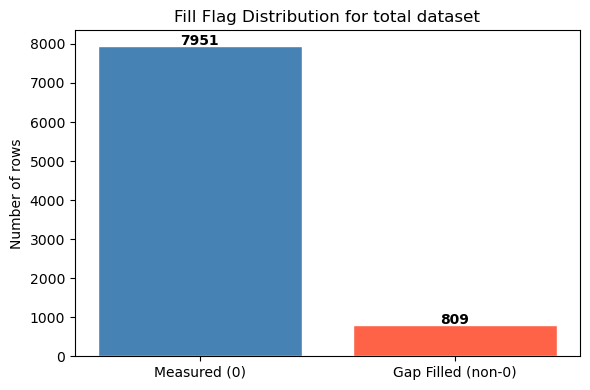

In [22]:
labels = ['Measured (0)', 'Gap Filled (non-0)']
values = [measured, filled]
colors = ['steelblue', 'tomato']
plt.figure(figsize=(6, 4))
plt.bar(labels, values, color=colors, edgecolor='white')
plt.title('Fill Flag Distribution for total dataset')
plt.ylabel('Number of rows')
for i, v in enumerate(values):
    plt.text(i, v + 20, str(v), ha='center', fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/figures/fill_flag_distribution.png', dpi=150)
plt.show()

- The NSRDB dataset uses a Fill Flag column to indicate whether the data is either filled or the actual values. 
- A value of 0 represents the measured value, and the non-zero values are gap-filled or the values handled by NREL's data quality control to ensure data quality 
- The dataset contains 90.8 % actual values and 9.2 % filled values, which will be an acceptable range for the model training, as most of them are real values 

In [23]:
df.drop(columns=['Fill Flag'], inplace=True)

---
<a id="outliers"></a>
## 6. Outlier Detection

Two complementary approaches are applied to detect anomalous GHI values:

1. **Statistical (IQR method):** Values below Q1 − 1.5·IQR or above Q3 + 1.5·IQR
2. **Physical bounds check:**
   - *Negative GHI:* Physically impossible (irradiance cannot be negative)
   - *GHI > 1,361 W/m²:* Exceeds the solar constant (total solar irradiance at
     the top of the atmosphere); surface values cannot legitimately exceed this

In [24]:
Q1 = df['GHI'].quantile(0.25)
Q3 = df['GHI'].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR
outliers = df[(df['GHI'] < lower) | (df['GHI'] > upper)]
impossible = df[df['GHI'] > 1361]
negative = df[df['GHI'] < 0]

print(f"\nGHI Outlier Analysis:")
print(f" Statistical outliers: {len(outliers)}")
print(f" Impossible values (>1361): {len(impossible)}")
print(f" Negative values: {len(negative)}")


GHI Outlier Analysis:
 Statistical outliers: 463
 Impossible values (>1361): 0
 Negative values: 0


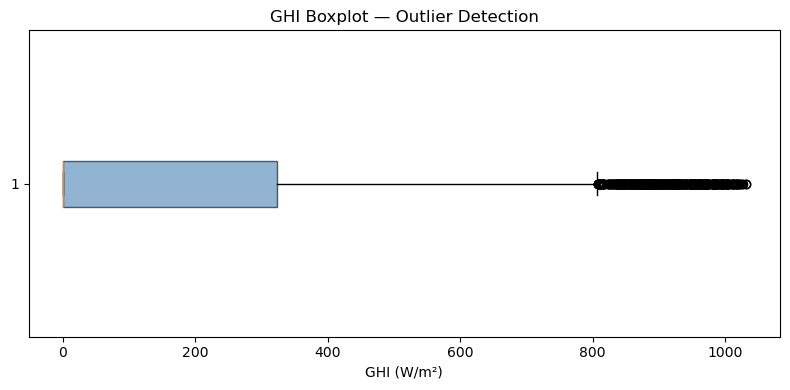

In [25]:
plt.figure(figsize=(8, 4))
plt.boxplot(df['GHI'], vert=False, patch_artist=True,
            boxprops=dict(facecolor='steelblue', alpha=0.6))
plt.title('GHI Boxplot — Outlier Detection')
plt.xlabel('GHI (W/m²)')
plt.tight_layout()
plt.savefig('../outputs/figures/ghi_boxplot.png', dpi=150)
plt.show()

From the boxplot, some values are flagged as outliers, but they are possible values in the solar dataset. So we shouldn't consider them outliers. These values should be considered artefacts.

---
<a id="eda"></a>
## 7. Exploratory Data Analysis

### 7.1 Frequency distribution of GHI

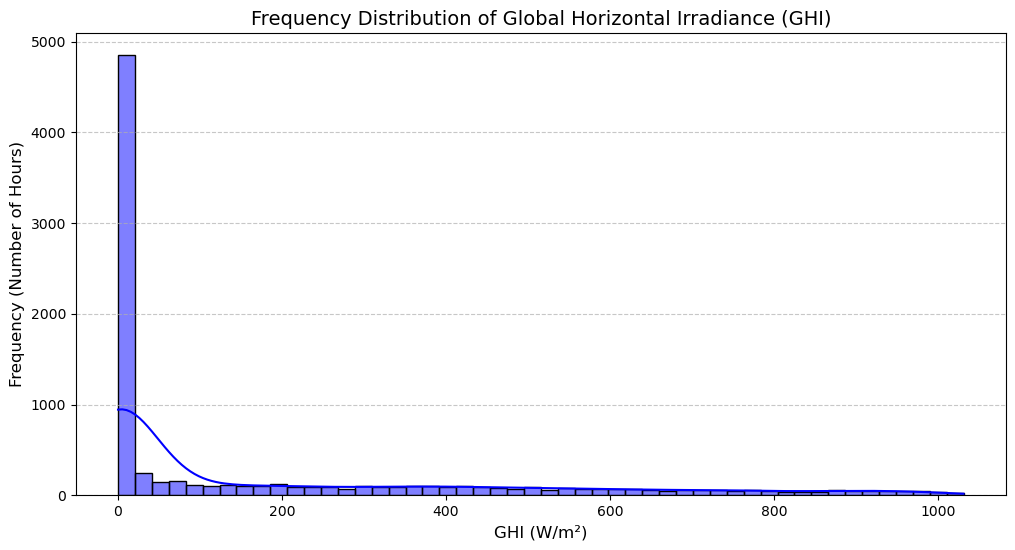

In [40]:
plt.figure(figsize=(12, 6))
sns.histplot(df['GHI'], bins=50, kde=True, color='blue')
plt.title('Frequency Distribution of Global Horizontal Irradiance (GHI)', fontsize=14)
plt.xlabel('GHI (W/m²)', fontsize=12)
plt.ylabel('Frequency (Number of Hours)', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.savefig('../outputs/figures/ghi_distribution.png', dpi=150)
plt.show()

**Observation of frequency distribution of the GHI** <br>
 The histogram shows the frequency distribution of the GHI values for all hours in 2022. It is right-skewed, with a high frequency of low values indicating the night-time and early morning hours, and the long tail represents the peak summer GHI values. 

In [27]:
print(f"Mean:     {df['GHI'].mean():.2f} W/m²")
print(f"Median:   {df['GHI'].median():.2f} W/m²")
print(f"Std Dev:  {df['GHI'].std():.2f} W/m²")
print(f"Skewness: {df['GHI'].skew():.4f}")
print(f"Kurtosis: {df['GHI'].kurt():.4f}")

Mean:     183.59 W/m²
Median:   0.00 W/m²
Std Dev:  277.10 W/m²
Skewness: 1.4151
Kurtosis: 0.7963


As our kurtosis values are less than 3, which states that all our values are close to the average values

### 7.2 Hourly GHI

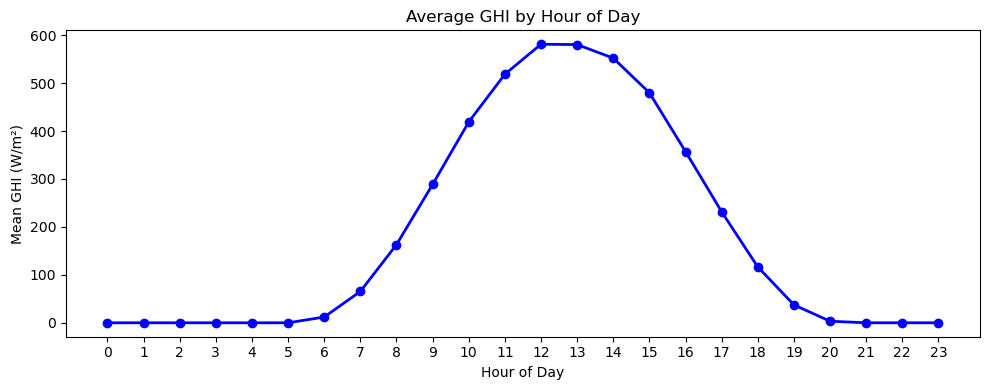

In [28]:
hourly_avg = df.groupby(df.index.hour)['GHI'].mean()

plt.figure(figsize=(10, 4))
plt.plot(hourly_avg.index, hourly_avg.values, 
         marker='o', color='blue', linewidth=2)
plt.title('Average GHI by Hour of Day')
plt.xlabel('Hour of Day')
plt.ylabel('Mean GHI (W/m²)')
plt.xticks(range(0, 24))
plt.tight_layout()
plt.savefig('../outputs/figures/ghi_by_hour.png', dpi=150)
plt.show()

**Observation of Hourly GHI**<br>
By plotting the hourly mean of GHI, we can state that our data is clean with a bell shape curve, with high GHI in the afternoon period and 0 around the night time

### 7.3 Monthly Average GHI recorded

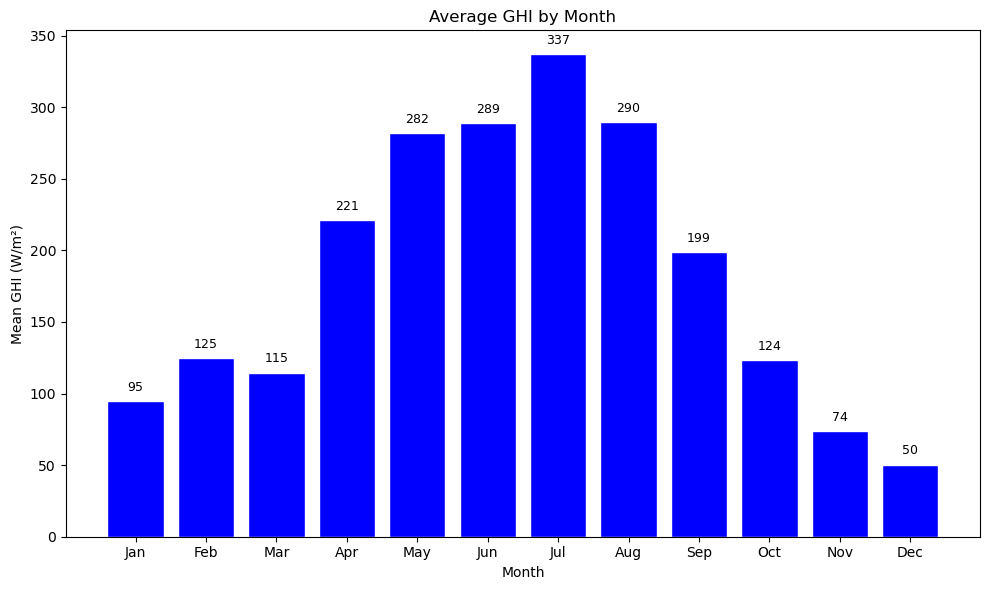

In [29]:
monthly_avg = df.groupby(df.index.month)['GHI'].mean()

plt.figure(figsize=(10, 6))
bars = plt.bar(monthly_avg.index, monthly_avg.values, 
               color='blue', edgecolor='white')
plt.title('Average GHI by Month')
plt.xlabel('Month')
plt.ylabel('Mean GHI (W/m²)')
plt.xticks(range(1, 13), ['Jan','Feb','Mar','Apr','May','Jun',
                           'Jul','Aug','Sep','Oct','Nov','Dec'])
for bar, val in zip(bars, monthly_avg.values):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 5,
             f'{val:.0f}', ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.savefig('../outputs/figures/ghi_by_month.png', dpi=150)
plt.show()

**Observation of Monthly GHI**<br>
By observing the monthly GHI, we can see that we have recorded high GHI values in summer and lower values in other seasons

### 7.4 GHI by Season

We have created a new categorical column based on the SPAIN seasons, making it easier to visualise them separately.

In [30]:
def season(month):
    if month in [12,1,2]:
        return 'Winter'
    elif month in [3,4,5]:
        return 'Spring'
    elif month in [6,7,8]:
        return 'Summer'
    else :
        return 'Autumn'
df['Season']=df.index.month.map(season)

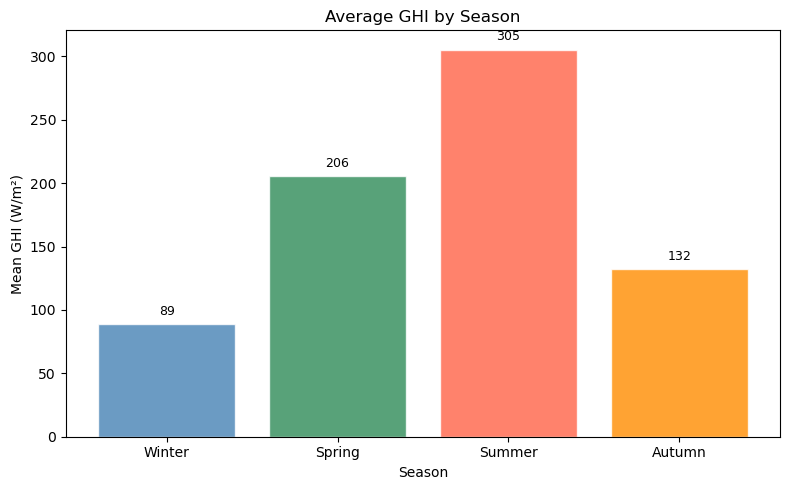

In [31]:
season_order = ['Winter', 'Spring', 'Summer', 'Autumn']
colors = ['steelblue', 'seagreen', 'tomato', 'darkorange']
season_means = [df[df['Season'] == s]['GHI'].mean() for s in season_order]

plt.figure(figsize=(8, 5))
bars = plt.bar(season_order, season_means, color=colors, 
               edgecolor='white', alpha=0.8)
for bar, val in zip(bars, season_means):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 5,
             f'{val:.0f}', ha='center', va='bottom', fontsize=9)
plt.title('Average GHI by Season')
plt.xlabel('Season')
plt.ylabel('Mean GHI (W/m²)')
plt.tight_layout()
plt.savefig('../outputs/figures/ghi_by_season_bar.png', dpi=150)
plt.show()

**Observation of Seasonal GHI**<br>
We can clearly say that our data is clean, as winter has the lowest recorded GHI and summer has the highest recorded GHI

C:\Users\srimu\AppData\Local\Temp\ipykernel_11824\954465892.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = plt.boxplot(season_data, labels=season_order, patch_artist=True)


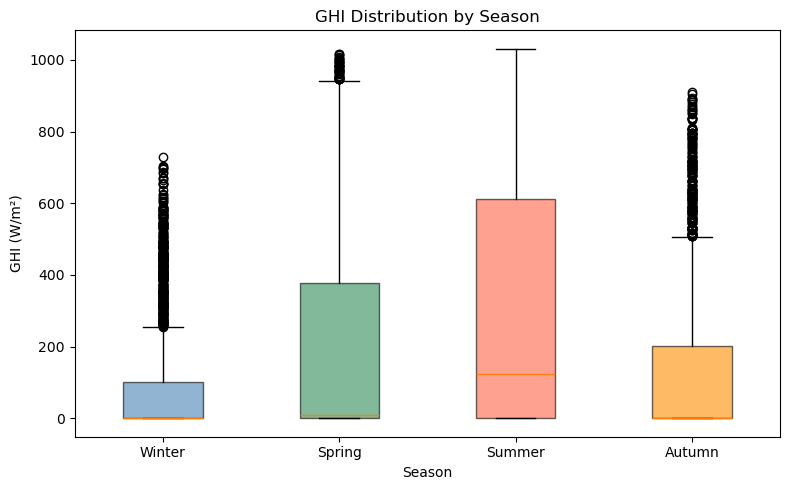

In [32]:
season_order = ['Winter', 'Spring', 'Summer', 'Autumn']

plt.figure(figsize=(8, 5))
season_data = [df[df['Season'] == s]['GHI'].values for s in season_order]
bp = plt.boxplot(season_data, labels=season_order, patch_artist=True)

colors = ['steelblue', 'seagreen', 'tomato', 'darkorange']
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)

plt.title('GHI Distribution by Season')
plt.xlabel('Season')
plt.ylabel('GHI (W/m²)')
plt.tight_layout()
plt.savefig('../outputs/figures/ghi_by_season.png', dpi=150)
plt.show()

Summer not only has the highest median GHI but also the 
greatest variability, likely due to variable cloud cover. 
Winter shows consistently low irradiance with minimal spread.

### 7.5 Sample time series plot (7 days)

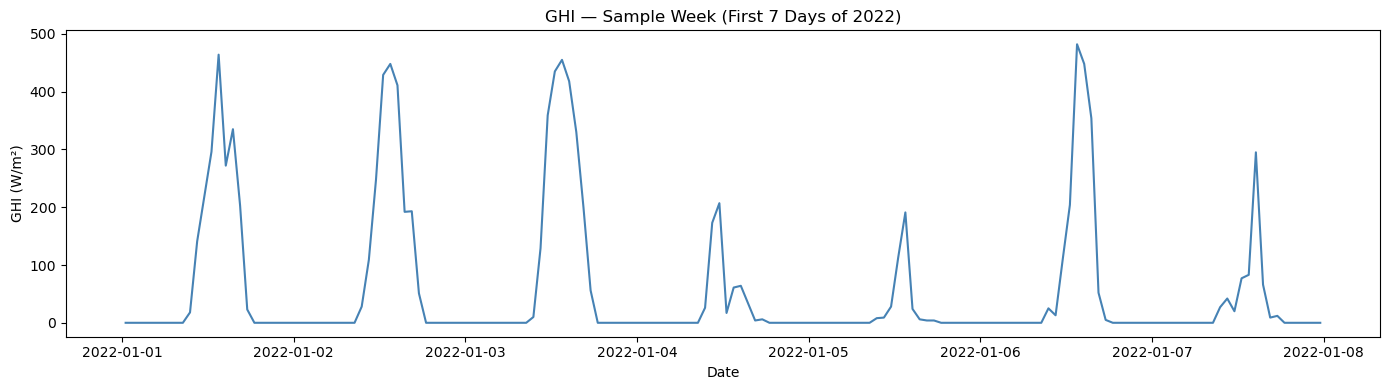

In [39]:
sample = df['GHI'].iloc[:24*7]

plt.figure(figsize=(14, 4))
plt.plot(sample.index, sample.values, color='steelblue', linewidth=1.5)
plt.title('GHI — Sample Week (First 7 Days of 2022)')
plt.xlabel('Date')
plt.ylabel('GHI (W/m²)')
plt.tight_layout()
plt.savefig('../outputs/figures/ghi_sample_week.png', dpi=150)
plt.show()

**Observation of Sample Week**<br>
<!-- [ADDED] — observation text for the 7-day plot -->
The 7-day sample confirms a clear daily bell-shaped cycle: GHI rises from zero at sunrise,
peaks around solar noon, and returns to zero at sunset. Day-to-day differences in peak height
reflect variable cloud cover, demonstrating both the deterministic diurnal pattern and
the stochastic variability that models need to capture.

---
<a id="feature"></a>
## 8. Feature Selection & Correlation Analysis

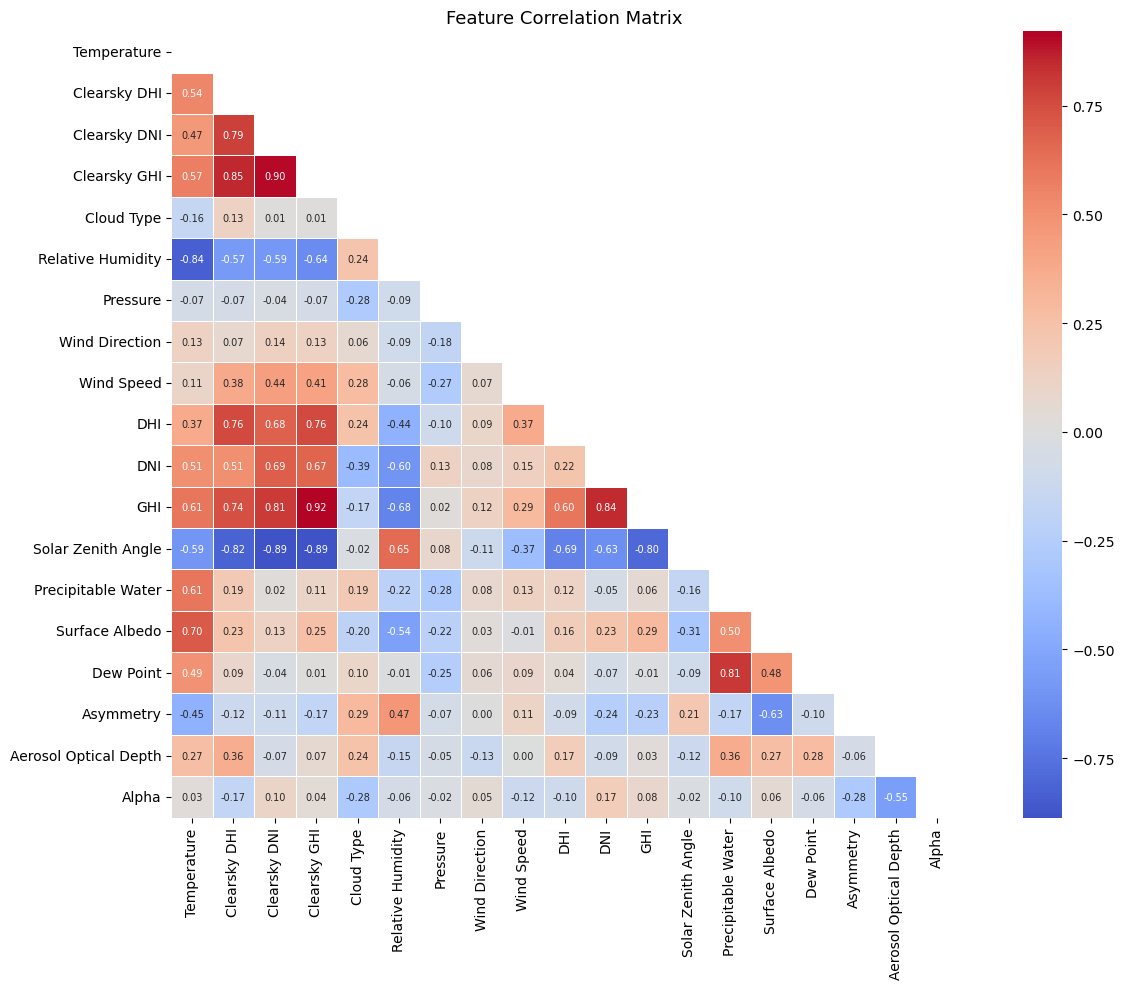

In [33]:
plt.figure(figsize=(14, 10))
corr = df.corr(numeric_only=True)
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, 
            annot=True, 
            fmt='.2f', 
            cmap='coolwarm',
            mask=mask,
            center=0,
            square=True,
            linewidths=0.5,
            annot_kws={'size': 7})
plt.title('Feature Correlation Matrix', fontsize=13)
plt.tight_layout()
plt.savefig('../outputs/figures/correlation_heatmap.png', dpi=150)
plt.show()

In [34]:
print("Top correlations with GHI:")
print(corr['GHI'].drop('GHI').sort_values(ascending=False).round(3))

Top correlations with GHI:
Clearsky GHI             0.921
DNI                      0.845
Clearsky DNI             0.805
Clearsky DHI             0.739
Temperature              0.607
DHI                      0.604
Surface Albedo           0.290
Wind Speed               0.286
Wind Direction           0.123
Alpha                    0.083
Precipitable Water       0.059
Aerosol Optical Depth    0.030
Pressure                 0.019
Dew Point               -0.015
Cloud Type              -0.172
Asymmetry               -0.234
Relative Humidity       -0.676
Solar Zenith Angle      -0.801
Name: GHI, dtype: float64


**Observation of Correlation Analysis**<br>
<!-- [ADDED] — interpretation of correlation results -->
The correlation matrix confirms that **Clearsky GHI** and **DNI** are the strongest predictors
of GHI, which is expected given their direct physical relationship. **Solar Zenith Angle** shows
a strong negative correlation — higher sun angles (closer to horizon) correspond to lower
irradiance. **Temperature** has a moderate positive correlation, reflecting the seasonal
co-variation of temperature and solar radiation. Features with correlations close to zero
(Pressure, Dew Point, Alpha, Aerosol Optical Depth, Asymmetry) are dropped in the export step.

### GHI vs Top 6 Correlated Features  

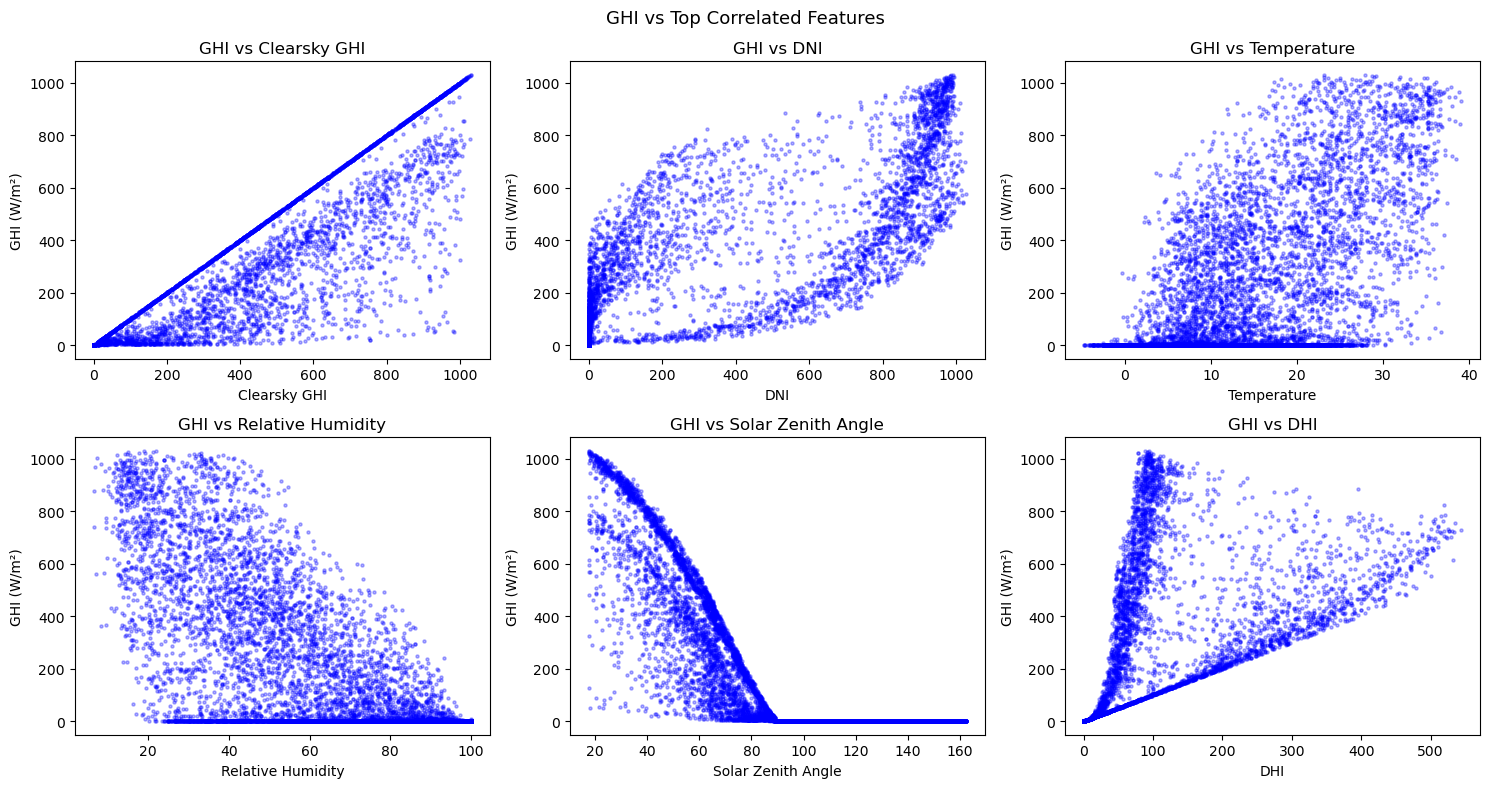

In [35]:
top_features = ['Clearsky GHI', 'DNI', 'Temperature', 
                'Relative Humidity', 'Solar Zenith Angle','DHI']

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, feature in enumerate(top_features):
    axes[i].scatter(df[feature], df['GHI'], 
                    alpha=0.3, s=5, color='blue')
    axes[i].set_xlabel(feature)
    axes[i].set_ylabel('GHI (W/m²)')
    axes[i].set_title(f'GHI vs {feature}')

plt.suptitle('GHI vs Top Correlated Features', fontsize=13)
plt.tight_layout()
plt.savefig('../outputs/figures/ghi_vs_features.png', dpi=150)
plt.show()

---
<a id="export"></a>
## 9. Export Processed Data

The processed full dataset is saved
to `../data/` as CSV files. The datetime index is preserved for all exports
to allow models to reconstruct temporal context.

In [37]:
cols_to_drop = [
    'Asymmetry',        # atmospheric parameter, correlation -0.234
    'Aerosol Optical Depth',  # very low correlation 0.030
    'Alpha',            # very low correlation 0.083
    'Pressure',         # near zero correlation 0.019
    'Dew Point',        # near zero correlation -0.015
]

df = df.drop(columns=cols_to_drop)
print(f"Remaining columns: {list(df.columns)}")
print(f"Dataset shape after dropping: {df.shape}")

Remaining columns: ['Temperature', 'Clearsky DHI', 'Clearsky DNI', 'Clearsky GHI', 'Cloud Type', 'Relative Humidity', 'Wind Direction', 'Wind Speed', 'DHI', 'DNI', 'GHI', 'Solar Zenith Angle', 'Precipitable Water', 'Surface Albedo', 'Season']
Dataset shape after dropping: (8760, 15)


In [38]:
df.to_csv('../data/df_processed.csv')
print(f"Final dataset saved: {df.shape}")
print(f"Date range: {df.index.min()} to {df.index.max()}")
print(f"Features: {list(df.columns)}")

Final dataset saved: (8760, 15)
Date range: 2022-01-01 00:30:00 to 2022-12-31 23:30:00
Features: ['Temperature', 'Clearsky DHI', 'Clearsky DNI', 'Clearsky GHI', 'Cloud Type', 'Relative Humidity', 'Wind Direction', 'Wind Speed', 'DHI', 'DNI', 'GHI', 'Solar Zenith Angle', 'Precipitable Water', 'Surface Albedo', 'Season']


---
<a id="summary"></a>
## 10. Preprocessing Summary
| Step | Action | Outcome |
|---|---|---|
| **Data loading** | NSRDB Spain Region, 2022, 1- hour resolution | 8760 rows  records |
| **DateTime index** | Constructed from Year/Month/Day/Hour/Minute columns | Complete, no gaps or duplicates |
| **Fill Flag** | Inspected — 90.8% measured, 9.2% gap-filled; column dropped | Dataset deemed fit for training |
| **Outlier detection** | IQR + physical bounds (GHI ≤ 1,361, ≥ 0) | No physically impossible values found |
| **Coorelation Analysis** |checked the coorelation between features|removed unwanted columns|
|**Export dataset**| cleaned the file by removing values| exported the cleaned dataset after preprocessing|                                                                                                  

### Features in Processed Dataset

| Feature | Type | Description |
|---|---|---|
| **GHI** | Target | Global Horizontal Irradiance — total solar radiation on a horizontal surface (W/m²) |
| DNI | Meteorological | Direct Normal Irradiance — beam radiation on a surface perpendicular to the sun (W/m²) |
| DHI | Meteorological | Diffuse Horizontal Irradiance — scattered sky radiation on a horizontal surface (W/m²) |
| Clearsky GHI | Meteorological | Modelled GHI under cloud-free atmospheric conditions (W/m²) |
| Clearsky DNI | Meteorological | Modelled DNI under cloud-free atmospheric conditions (W/m²) |
| Clearsky DHI | Meteorological | Modelled DHI under cloud-free atmospheric conditions (W/m²) |
| Temperature | Meteorological | Air temperature at 2 m above ground level (°C) |
| Relative Humidity | Meteorological | Ratio of actual to saturation water vapour pressure at 2 m (%) |
| Wind Speed | Meteorological | Wind speed at 10 m above ground level (m/s) |
| Wind Direction | Meteorological | Wind direction at 10 m — 0° = North, 90° = East, 180° = South (°) |
| Precipitable Water | Meteorological | Total atmospheric water vapour in a vertical column, surface to TOA (cm) |
| Surface Albedo | Meteorological | Fraction of incoming solar radiation reflected by the surface (0–1) |
| Solar Zenith Angle | Astronomical | Angle between the sun and local vertical — 0° = overhead, 90° = horizon (°) |
| Cloud Type | Categorical | NSRDB cloud classification — 0 = clear sky, 1–8 = cloud type categories |
| Season | Derived | Meteorological season assigned from month — Winter, Spring, Summer, Autumn |